# Hypothesis Testing

Our story of statistical hypothesis testing begins with Dr. Ron Fisher and Dr. Muriel Bristol who were colleagues at a British research station right after World War I. The story begins with a meeting where Ron offered Muriel a cup tea. The results were surprising and changed the course of scientific research forever. [This Wikipedia article has details.](https://en.wikipedia.org/wiki/Lady_tasting_tea)

To calculate the probabilities involved, we need the formula for combinations from our [course notes](https://straightdraw.github.io/probstat/P2a.html#wrapping-up). Also, we will need to load the **Mosaic** package.

In [13]:
combin <- function(n, k) {
    return(factorial(n) / ( factorial(k)*factorial(n-k) )) }
library('mosaic')

## Binomial Distribution

While Ron Fisher used a slightly different approach, we can use the Binomial Distribution with a 50\% chance of success. For example, the probability of exactly six successes in eight trials for random guessing would be as follows:

In [14]:
x = 6    # Number of successes out of 8 trials
bin <- combin(8,x)*(1/2)^x*(1/2)^(8-x)     # Binomial distribution evaluation
bin

[1] 0.109375

## Empirical Probabilities

We can use the **rflip()** function in R to simulate flipping a fair coin 8 eight times which was Ron Fisher's null hypothesis:

- $H_0 : \pi = \frac{1}{2}$
- $H_a : \pi > \frac{1}{2}$

An example using the *mosaic* function **rflip()** is shown below.

In [15]:
rflip(25, prob = 1/2, summarize = TRUE)

n,heads,tails,prob
<dbl>,<int>,<dbl>,<dbl>
25,8,17,0.5


## Testing

We will test the machinery to make sure we have everything working properly. In the code below, we generate the summary table for 8 coin flips and name it **successes**. Then, from the **successes** summary we access the 2nd item (number of heads).

In [16]:
successes <- rflip(8, prob = 1/2, summarize = TRUE)
successes
successes[1,2]

n,heads,tails,prob
<dbl>,<int>,<dbl>,<dbl>
8,2,6,0.5


[1] 2

## Loop

I have copied the **for loop** from section 2 notebooks and tweaked the code for our example.

Times Number of Successes was Equal to 7 :  8 
  which gives p =  0.008

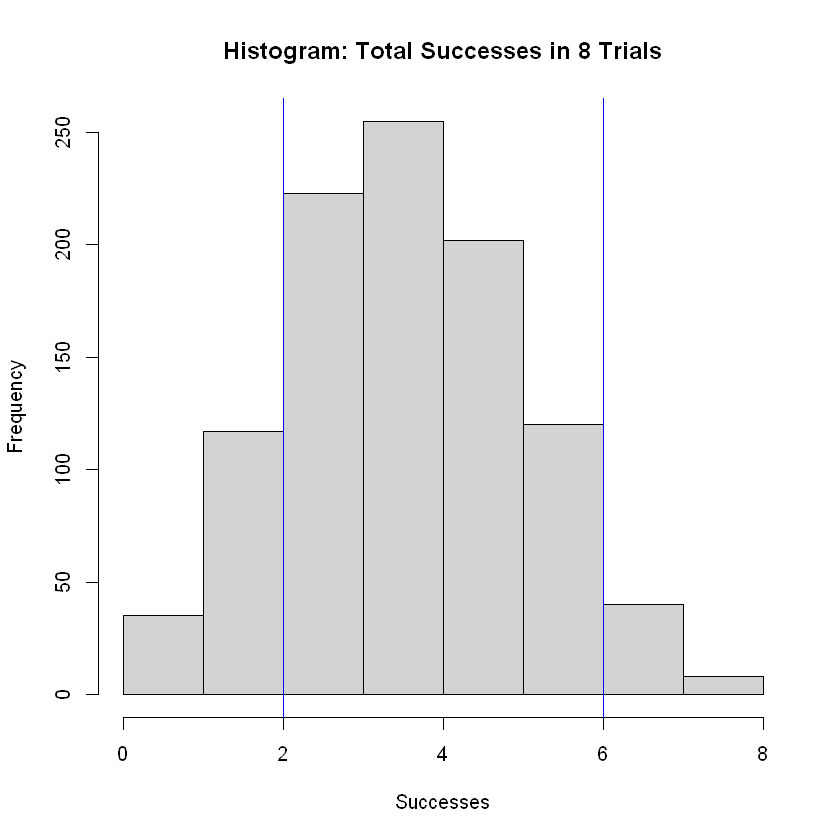

In [17]:
total_successes <- c()     #Empty vector to store number of successes in each trial

for (count in 1:1000){
    successes <- rflip(8, prob = 1/2, summarize = TRUE)
    total_successes[count] <- successes[1,2]
}

upper <- quantile(total_successes, prob = 0.95)
lower <- quantile(total_successes, prob = 0.05)
cat('Times Number of Successes was Equal to 7 : ', sum(total_successes==8), '\n  which gives p = ',sum(total_successes==8)/1000)
hist(total_successes, main = 'Histogram: Total Successes in 8 Trials', xlab = 'Successes')
abline( v = lower, col="blue")
abline(v = upper, col="blue")

## Task 1

Let's simulate the situation several times and verify the theoretical probabilities above.

## Task 2

The hypothesis for the cross-country example follows:

$$\begin{align*}H_0 : \mu &= 75\\H_a : \mu &< 75\end{align*}$$

The data for the cross-country team's resting heart rates is given below.

In [18]:
data <- c(82, 74, 67, 79, 71, 75, 59, 64, 60, 79, 65)

## Task 3: The First Hypothesis Test

The solution devised by Ron Fischer and his officemate was to offer a taste test. A total of 8 cups of tea would be served to Muriel, 4 with tea added first and 4 with milk added first. Let's calculate the probability of Muriel get, 6, 7 or 8 correct out of 8 given that she was guessing, e.g. had a 50% chance of success.

In [19]:
results_6 <-binom.test(6, 8, p = 0.5, alternative = "greater", conf.level = 0.95)
results_7 <- binom.test(7, 8, p = 0.5, alternative = "greater", conf.level = 0.95)
results_8 <- binom.test(8, 8, p = 0.5, alternative = "greater", conf.level = 0.95)

In [20]:
cat('The probability of Muriel answering correctly if she was guessing:\n
   6 out of 8 correct would have a probability of ', results_6$p.value , '\n
   7 out of 8 correct would have a probability of ', results_7$p.value , '\n
   8 out of 8 correct would have a probability of ', results_8$p.value )

The probability of Muriel answering correctly if she was guessing:

   6 out of 8 correct would have a probability of  0.1445313 

   7 out of 8 correct would have a probability of  0.03515625 

   8 out of 8 correct would have a probability of  0.00390625